### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [25]:
import tensorflow as tf
from tensorflow import data
from tensorflow.keras import layers, Model, utils, callbacks, optimizers
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [8]:
import albumentations as A

### Step 2: Constant

In [9]:
AUTO = data.experimental.AUTOTUNE
DATA_FOLD = './data/lung_colon_image_set/lung_image_sets/'
IMG_HEIGH = 256
IMG_WIDTH = 256
IMG_CHANNEL = 3
BATCH_SIZE = 64
EPOCHS = 20
NUM_CLASSES = 3

### Step 3: Load Data

In [10]:
df = pd.DataFrame()
for label in os.listdir(DATA_FOLD):
    img_ids = os.listdir(f'{DATA_FOLD}{label}')
    temp = pd.DataFrame(
        {
            'img_id': os.listdir(f'{DATA_FOLD}{label}'),
            'label': label
        }
    )
    df = pd.concat([df, temp], axis=0, ignore_index=True)

In [11]:
df.sample(5)

,img_id,label
7700,lungn3429.jpeg,lung_n
11197,lungscc2076.jpeg,lung_scc
9454,lungn507.jpeg,lung_n
14337,lungscc4902.jpeg,lung_scc
8517,lungn4164.jpeg,lung_n


### Step 4: Exploaring Data

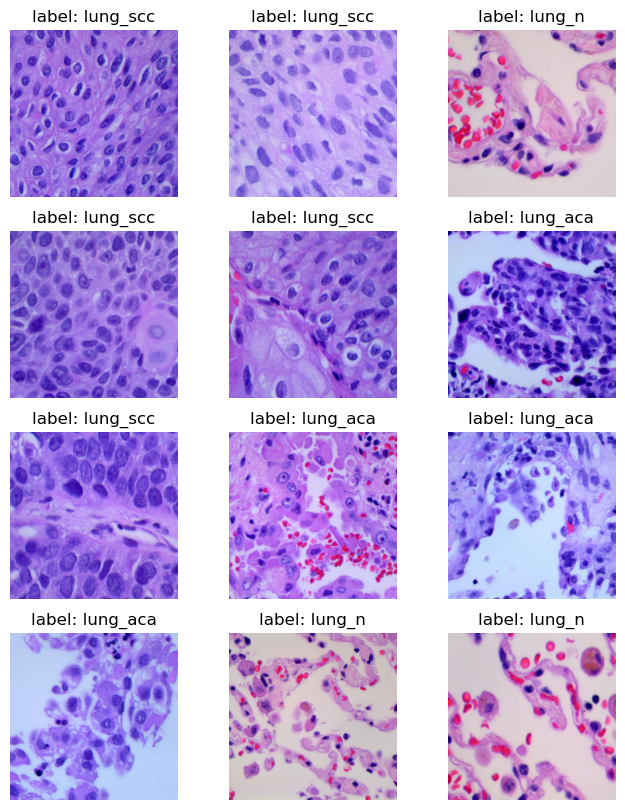

In [12]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(df.shape[0])
    label = df.loc[k, 'label']
    img_id = df.loc[k, 'img_id']
    img = plt.imread(f'{DATA_FOLD}{label}/{img_id}')
    plt.imshow(img)
    plt.title(f'label: {label}')
    plt.axis('off')

### Step 5: Preparing Data

#### Label encode

In [13]:
le = LabelEncoder()

In [14]:
df['label_id'] = le.fit_transform(df['label'])

#### Split Data

In [15]:
train, value = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [16]:
value, test = train_test_split(
    value,
    test_size=0.5,
    random_state=42
)

In [17]:
print(len(train), len(value), len(test))

9000 3000 3000


#### Albumentation

In [19]:
preparing = A.Resize(IMG_HEIGH, IMG_WIDTH)

In [18]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2),
        A.CoarseDropout(p=0.2)
    ]
)

#### Build Generator

In [20]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['img_id']
            label_id = row['label_id']
            label = row['label']
            img = cv2.imread(f'{DATA_FOLD}{label}/{img_id}')
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = preparing(image=img)['image']
            if is_train:
                img = transform(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, label_id

    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [21]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [24]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [23]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 256, 256, 3) (64, 3)


### Step 6: Model Development

#### Build Model

In [26]:
pre_trained_model = InceptionV3(
    input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL),
    weights='imagenet',
    include_top=False
)

In [30]:
pre_trained_model.trainable = False

In [32]:
pre_trained_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 127, 127, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 127, 127, 32)      │              96 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 127, 127, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 125, 125, 32)      │           9,216 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 125, 125, 32)      │              96 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 125, 125, 32)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 125, 125, 64)      │          18,432 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 125, 125, 64)      │             192 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 125, 125, 64)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 62, 62, 64)        │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 62, 62, 80)        │           5,120 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 62, 62, 80)        │             240 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 62, 62, 80)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 60, 60, 192)       │         138,240 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [38]:
x = pre_trained_model.get_layer('mixed8').output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

In [39]:
model = Model(pre_trained_model.input, outputs)

In [40]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 127, 127, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 127, 127, 32)      │              96 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 127, 127, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 125, 125, 32)      │           9,216 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 125, 125, 32)      │              96 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 125, 125, 32)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 125, 125, 64)      │          18,432 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 125, 125, 64)      │             192 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 125, 125, 64)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 62, 62, 64)        │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 62, 62, 80)        │           5,120 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 62, 62, 80)        │             240 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 62, 62, 80)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 60, 60, 192)       │         138,240 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 22,506,403 (85.86 MB)

 Trainable params: 11,830,787 (45.13 MB)

 Non-trainable params: 10,675,616 (40.72 MB)

#### Compile Model

In [42]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [43]:
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Train Model

In [45]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [46]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=0
)

In [47]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9057 - loss: 0.2706 - val_accuracy: 0.9557 - val_loss: 0.1375 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9507 - loss: 0.1381 - val_accuracy: 0.9787 - val_loss: 0.0628 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9657 - loss: 0.0883 - val_accuracy: 0.9753 - val_loss: 0.0608 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9689 - loss: 0.0866 - val_accuracy: 0.9850 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9731 - loss: 0.0715 - val_accuracy: 0.9870 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9776 - loss: 0.0581 - val_accuracy: 0.9820 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9796 - loss: 0.

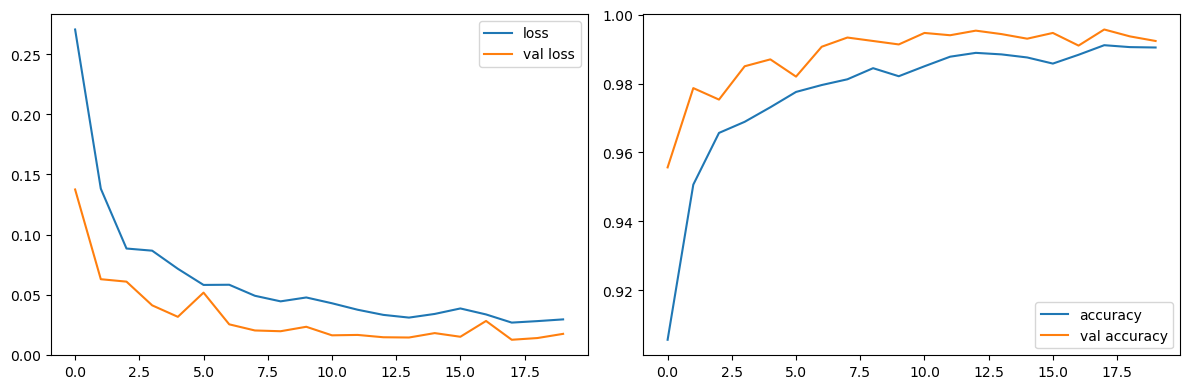

In [49]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [50]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.017, test accuracy: 0.995


In [51]:
test_pred = model.predict(test_generator)

47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step


In [52]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

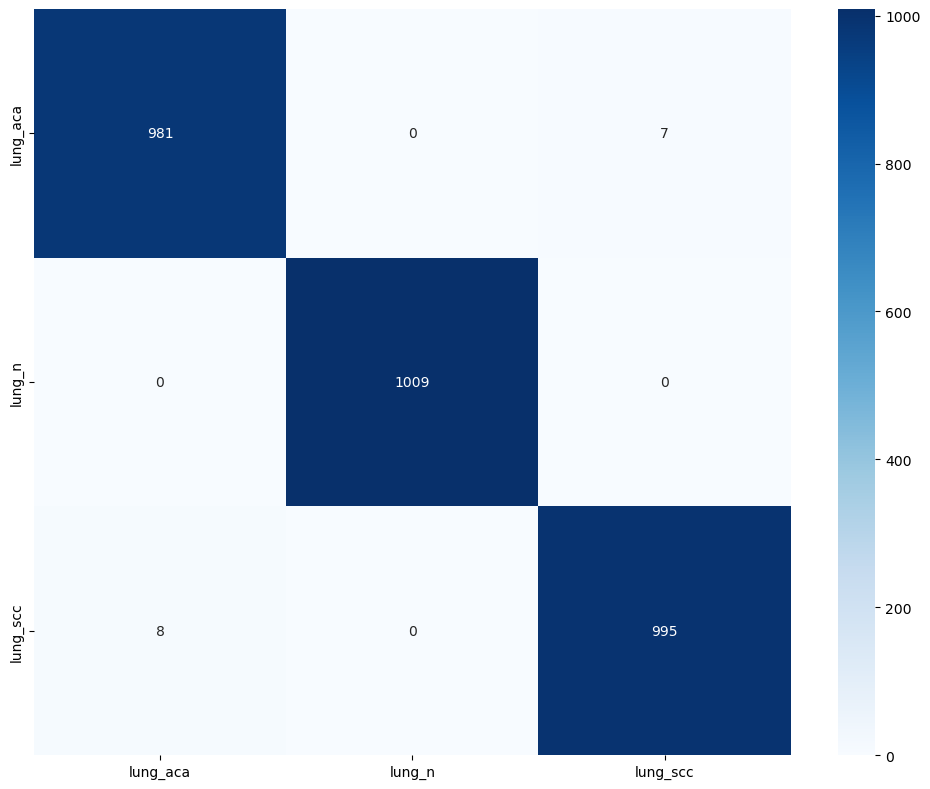

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()